In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.json
/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.csv


In [2]:
import re
import nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

## Data Acq.

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zynicide/wine-reviews/winemag-data_first150k.csv")
print(f'150k Df Shape : {df.shape}')

150k Df Shape : (150930, 11)


## Data Samples

In [4]:
pd.set_option('display.max_colwidth', None)
df[["description"]].head()

,description
0,"This tremendous 100% varietal wine hails from Oakville and was aged over three years in oak. Juicy red-cherry fruit and a compelling hint of caramel greet the palate, framed by elegant, fine tannins and a subtle minty tone in the background. Balanced and rewarding from start to finish, it has years ahead of it to develop further nuance. Enjoy 2022–2030."
1,"Ripe aromas of fig, blackberry and cassis are softened and sweetened by a slathering of oaky chocolate and vanilla. This is full, layered, intense and cushioned on the palate, with rich flavors of chocolaty black fruits and baking spices. A toasty, everlasting finish is heady but ideally balanced. Drink through 2023."
2,"Mac Watson honors the memory of a wine once made by his mother in this tremendously delicious, balanced and complex botrytised white. Dark gold in color, it layers toasted hazelnut, pear compote and orange peel flavors, reveling in the succulence of its 122 g/L of residual sugar."
3,"This spent 20 months in 30% new French oak, and incorporates fruit from Ponzi's Aurora, Abetina and Madrona vineyards, among others. Aromatic, dense and toasty, it deftly blends aromas and flavors of toast, cigar box, blackberry, black cherry, coffee and graphite. Tannins are polished to a fine sheen, and frame a finish loaded with dark chocolate and espresso. Drink now through 2032."
4,"This is the top wine from La Bégude, named after the highest point in the vineyard at 1200 feet. It has structure, density and considerable acidity that is still calming down. With 18 months in wood, the wine has developing an extra richness and concentration. Produced by the Tari family, formerly of Château Giscours in Margaux, it is a wine made for aging. Drink from 2020."


## NLTK Setup

In [5]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Basic Stats

In [6]:
desc = df[["description"]].copy()

desc["char_count"] = desc["description"].str.len()
desc["word_count"] = desc["description"].str.split().str.len()
desc["sent_count"] = desc["description"].str.split('.').str.len()

print("=== Basic Description Stats ===")
desc[["char_count","word_count","sent_count"]].head(5)

=== Basic Description Stats ===


,char_count,word_count,sent_count
0,355,60,5
1,318,51,5
2,280,47,3
3,386,62,5
4,376,66,6


## Missing Value

In [7]:
missing = desc["description"].isna().sum()
print(f"\nMissing Values : {missing} ({missing/len(desc)*100}%)")


Missing Values : 0 (0.0%)


## Word count distribution

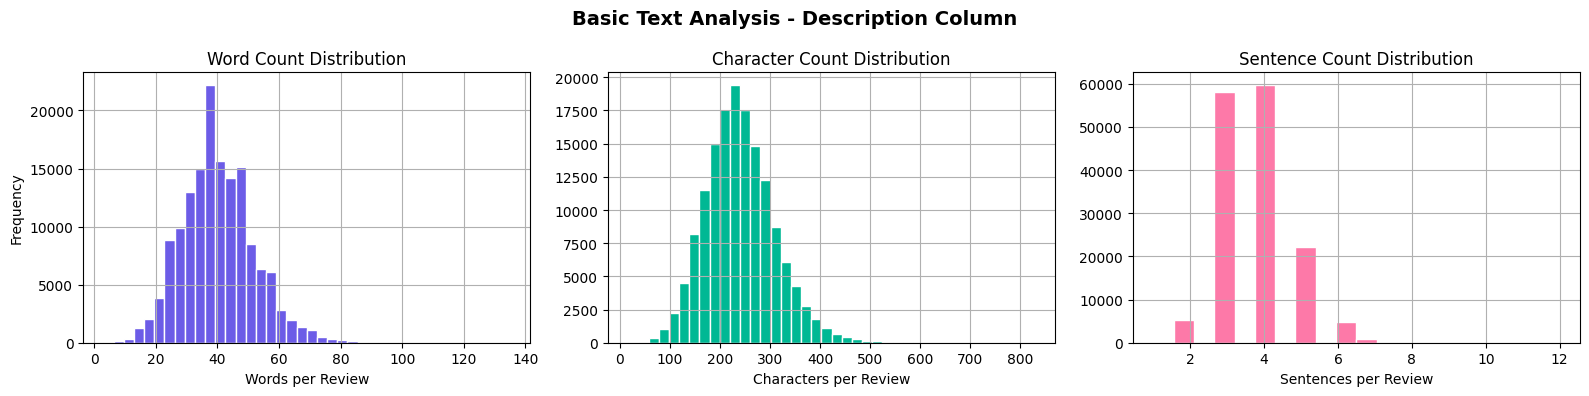

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Basic Text Analysis - Description Column", fontsize=14, fontweight='bold')

desc["word_count"].hist(bins=40, ax=axes[0], color="#6c5ce7", edgecolor='white')
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words per Review")
axes[0].set_ylabel("Frequency")

desc["char_count"].hist(bins=40, ax=axes[1], color="#00b894", edgecolor='white')
axes[1].set_title("Character Count Distribution")
axes[1].set_xlabel("Characters per Review")

desc["sent_count"].hist(bins=20, ax=axes[2], color="#fd79a8", edgecolor='white')
axes[2].set_title("Sentence Count Distribution")
axes[2].set_xlabel("Sentences per Review")

plt.tight_layout()
plt.show()

## Most Frequent Words

In [9]:
stop_words = set(stopwords.words('english'))
# domain specific to add to stop word
domain_stops = {"wine", "wines", "drink", "flavor", "flavors", "palate", 
                "finish", "nose", "aromas", "notes", "offers", "shows"}
stop_words.update(domain_stops)

def get_tokens(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    tokens = word_tokenize(text)
    # eliminate the text if exist on stopwords and word with only 2 or less chars
    return [t for t in tokens if t not in stop_words and len(t) > 2]

print("\nTokenizing... (might take a moment)")
desc["tokens"] = desc["description"].apply(get_tokens)

all_words = [word for tokens in desc["tokens"] for word in tokens]
word_freq  = Counter(all_words)
top_words  = word_freq.most_common(20)


Tokenizing... (might take a moment)


## Bar chart top words

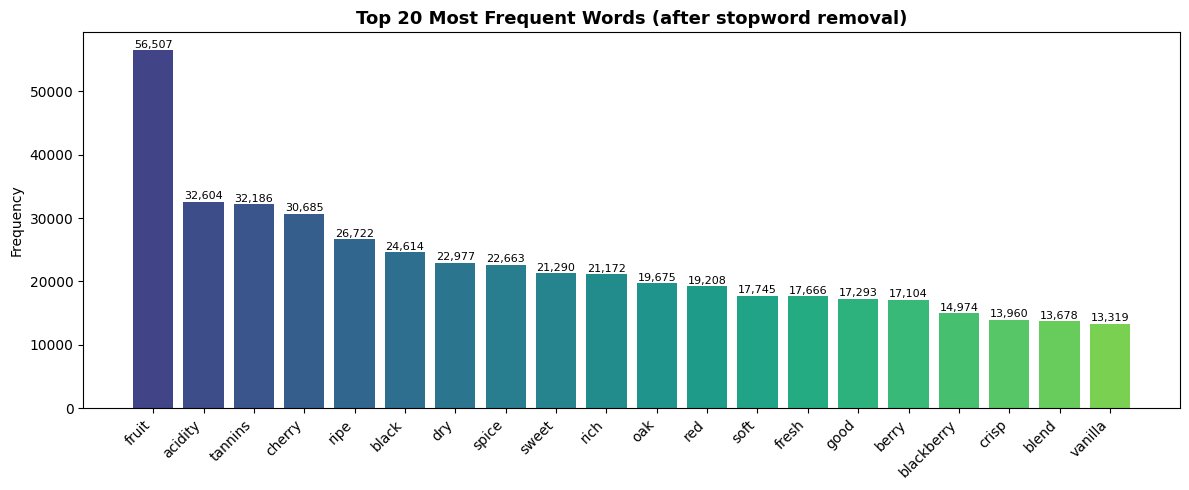

In [10]:
words, counts = zip(*top_words)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=plt.cm.viridis(np.linspace(0.2, 0.8, len(words))))
plt.title("Top 20 Most Frequent Words (after stopword removal)", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Frequency")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
desc[["tokens"]].head()

,tokens
0,"[tremendous, varietal, hails, oakville, aged, three, years, oak, juicy, redcherry, fruit, compelling, hint, caramel, greet, framed, elegant, fine, tannins, subtle, minty, tone, background, balanced, rewarding, start, years, ahead, develop, nuance, enjoy]"
1,"[ripe, fig, blackberry, cassis, softened, sweetened, slathering, oaky, chocolate, vanilla, full, layered, intense, cushioned, rich, chocolaty, black, fruits, baking, spices, toasty, everlasting, heady, ideally, balanced]"
2,"[mac, watson, honors, memory, made, mother, tremendously, delicious, balanced, complex, botrytised, white, dark, gold, color, layers, toasted, hazelnut, pear, compote, orange, peel, reveling, succulence, residual, sugar]"
3,"[spent, months, new, french, oak, incorporates, fruit, ponzis, aurora, abetina, madrona, vineyards, among, others, aromatic, dense, toasty, deftly, blends, toast, cigar, box, blackberry, black, cherry, coffee, graphite, tannins, polished, fine, sheen, frame, loaded, dark, chocolate, espresso]"
4,"[top, bgude, named, highest, point, vineyard, feet, structure, density, considerable, acidity, still, calming, months, wood, developing, extra, richness, concentration, produced, tari, family, formerly, chteau, giscours, margaux, made, aging]"


## Word Cloud

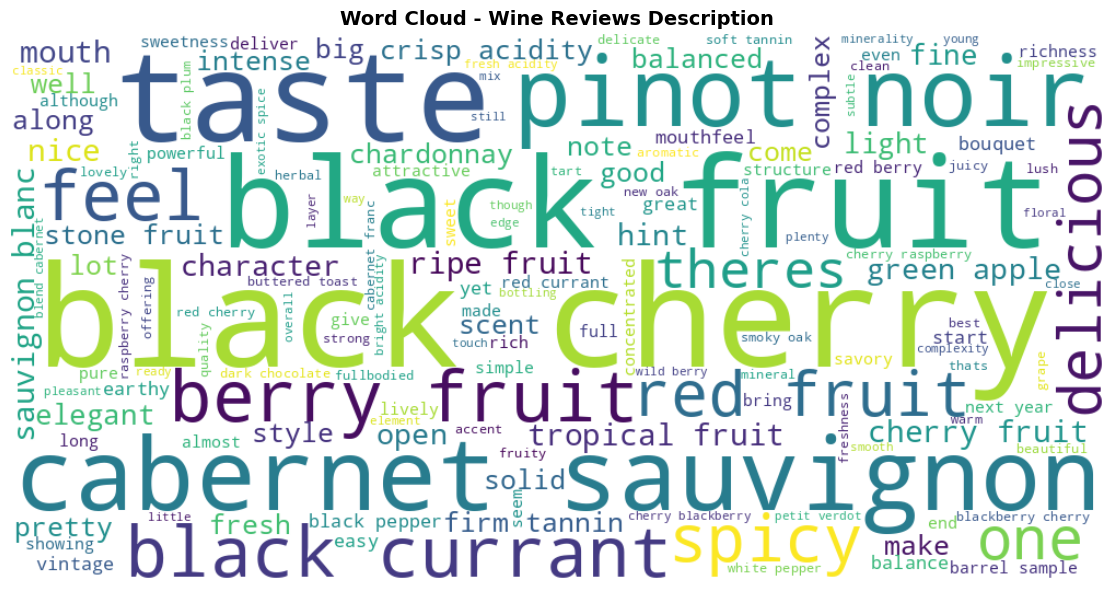

In [12]:
wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(' '.join(all_words))

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Wine Reviews Description", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()